-----------------------------------------------------------------
S&P 500 LARGE MOVEMENT ANALYSIS
-----------------------------------------------------------------



[                       0%                       ]

Fetched 503 tickers



[*********************100%***********************]  503 of 503 completed


Processed 50/503 stocks...
Processed 100/503 stocks...
Processed 150/503 stocks...
Processed 200/503 stocks...
Processed 250/503 stocks...
Processed 300/503 stocks...
Processed 350/503 stocks...
Processed 400/503 stocks...
Processed 450/503 stocks...
Processed 500/503 stocks...
Found 503 qualifying events

-----------------------------------------------------------------
SUMMARY
-----------------------------------------------------------------
Total events: 503
Large gains: 274
Large drops: 229

-----------------------------------------------------------------
AFTER 10%+ GAINS
-----------------------------------------------------------------
Next day (avg): 0.58%  |  up: 52.2%
Next week (avg): 1.47%  |  up: 55.1%

-----------------------------------------------------------------
AFTER 10%+ DROPS
-----------------------------------------------------------------
Next day (avg): 0.79%  |  up: 56.3%
Next week (avg): 1.96%  |  up: 58.5%

-----------------------------------------------------

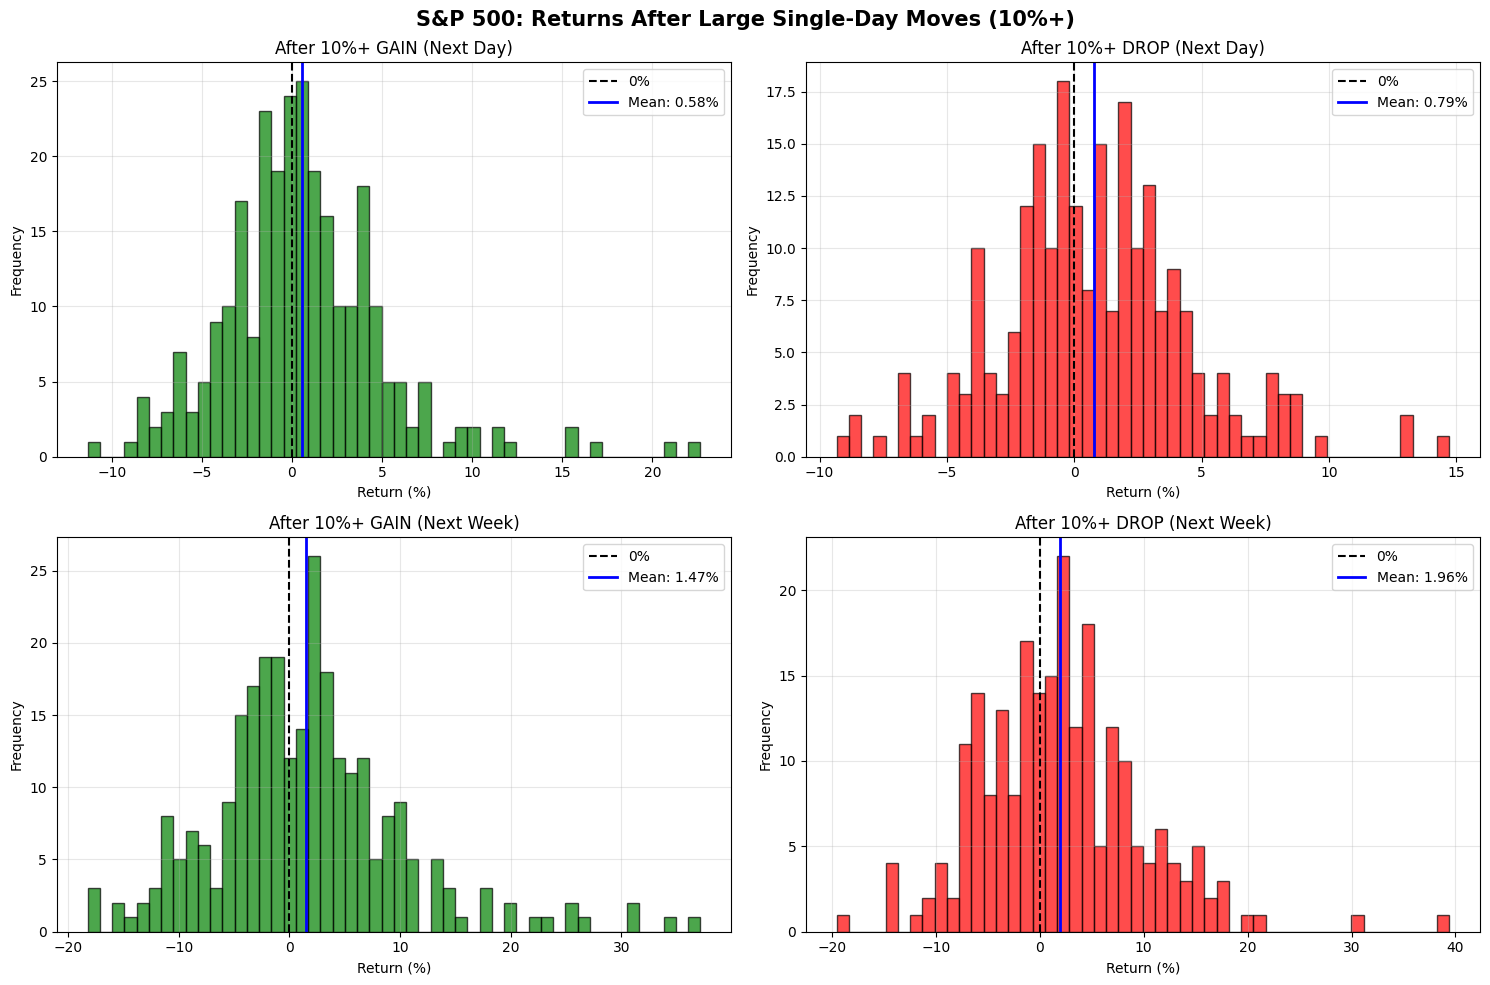

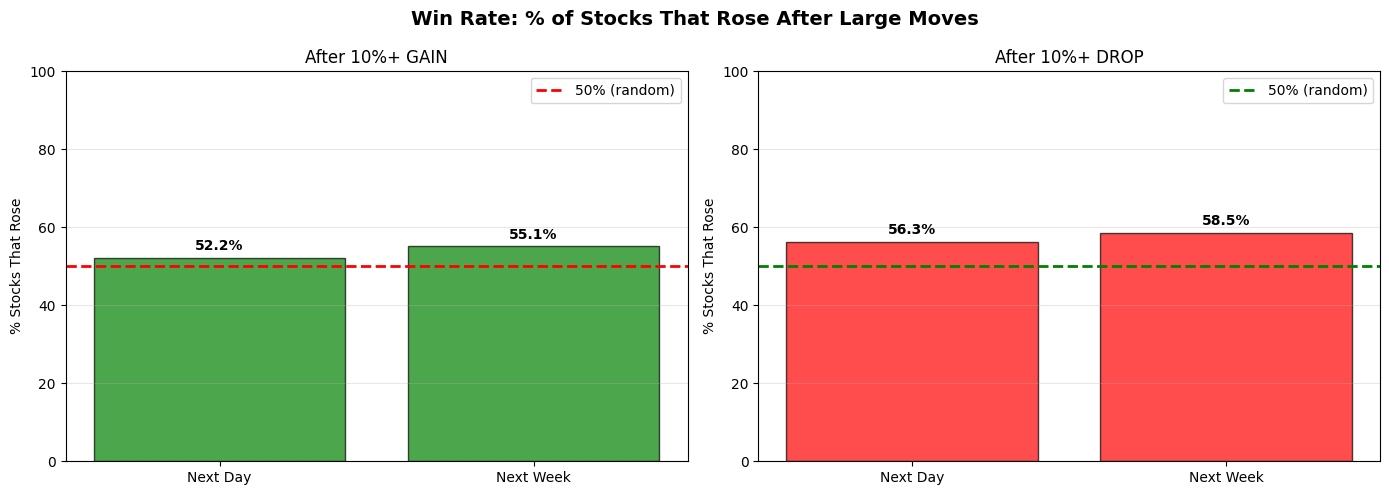

In [8]:
# Analysis of Stock Movement of 10%+ in S&P 500 
# ----------------------------------------------------------------------------------------------------

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from datetime import datetime, timedelta
from io import StringIO
import requests

# ----------------------------------------------------------------------------------------------------
# CONFIGURATIONS
# ----------------------------------------------------------------------------------------------------

THRESHOLD   = 0.10      # this is the minimum amount a stock needs to move to trigger an event (%)
HOLD_DAYS   = 5         # the no. of trading days to measure returns after an event
VIX_ACTIVE  = 20        # only trade if VIX is above this 

# ----------------------------------------------------------------------------------------------------
# PULLING THE TICKERS
# ----------------------------------------------------------------------------------------------------

def get_sp500_tickers():
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        response = requests.get(url, headers=headers)
        tables = pd.read_html(StringIO(response.text))
        sp500_table = tables[0]
        tickers = sp500_table['Symbol'].tolist()
        tickers = [ticker.replace('.', '-') for ticker in tickers]
        return tickers
    except: # Fail case of tickers obtained from Claude
        print("WARNING: Could not fetch S&P 500 list. Using fallback subset.")
        return [
            'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'LLY', 'AVGO',
            'JPM', 'V', 'UNH', 'XOM', 'WMT', 'MA', 'JNJ', 'PG', 'COST', 'HD',
            'NFLX', 'BAC', 'ABBV', 'CRM', 'KO', 'ORCL', 'MRK', 'CVX', 'AMD', 'PEP',
            'ACN', 'ADBE', 'TMO', 'LIN', 'MCD', 'CSCO', 'DIS', 'ABT', 'WFC', 'INTC',
            'QCOM', 'VZ', 'DHR', 'TXN', 'CMCSA', 'PM', 'INTU', 'AMGN', 'IBM', 'COP',
            'NEE', 'HON', 'UNP', 'RTX', 'LOW', 'CAT', 'SPGI', 'AMAT', 'PFE', 'BA',
            'GE', 'UBER', 'BLK', 'DE', 'T', 'ELV', 'SYK', 'AXP', 'MS', 'MDT',
            'BKNG', 'GILD', 'TJX', 'PLD', 'VRTX', 'ADI', 'CI', 'SCHW', 'REGN', 'MMC',
            'C', 'LRCX', 'CB', 'SBUX', 'FI', 'ISRG', 'SO', 'MO', 'BMY', 'NOC',
            'AMT', 'PYPL', 'ETN', 'BSX', 'DUK', 'WM', 'ZTS', 'PGR', 'ITW', 'EOG',
            'APH', 'CME', 'BDX', 'AON', 'CL', 'CSX', 'MCO', 'GD', 'EMR', 'EQIX',
            'MMM', 'ICE', 'SLB', 'PH', 'HCA', 'NSC', 'USB', 'PSA', 'MDLZ', 'APD',
            'TGT', 'SHW', 'MAR', 'KLAC', 'GM', 'ECL', 'SNPS', 'MSI', 'WELL', 'ADM',
            'MCK', 'ADP', 'MPC', 'F', 'ROP', 'CDNS', 'TT', 'CCI', 'NXPI', 'ORLY',
            'COIN', 'AJG', 'TDG', 'PCAR', 'PSX', 'AFL', 'OKE', 'JCI', 'FDX', 'CMG',
            'AIG', 'SRE', 'FTNT', 'AZO', 'TRV', 'TEL', 'MNST', 'HUM', 'D', 'KMB',
            'ROST', 'AEP', 'PAYX', 'ALL', 'GIS', 'MSCI', 'SPG', 'HLT', 'CARR', 'O',
            'KMI', 'NEM', 'ANET', 'PRU', 'CTVA', 'FAST', 'DLR', 'BK', 'YUM', 'EA',
            'PCG', 'SYY', 'ODFL', 'CMI', 'IDXX', 'RSG', 'KHC', 'VRSK', 'CPRT', 'KR',
            'DD', 'CTAS', 'IT', 'GWW', 'OTIS', 'XEL', 'MCHP', 'EW', 'AME', 'BKR',
            'KEYS', 'HES', 'VMC', 'A', 'EXC', 'IQV', 'ROK', 'ACGL', 'RMD', 'VICI',
            'HSY', 'DOW', 'PPG', 'TROW', 'MTD', 'GEHC', 'ANSS', 'DVN', 'GLW', 'IR',
            'WMB', 'MLM', 'HAL', 'WTW', 'EXR', 'PWR', 'FANG', 'EFX', 'LHX', 'LVS',
            'DXCM', 'ED', 'CEG', 'CHTR', 'DAL', 'STZ', 'HPQ', 'CTSH', 'DHI', 'CAH',
            'URI', 'LEN', 'CBRE', 'VLO', 'FTV', 'WAB', 'DFS', 'CDW', 'WEC', 'TSCO',
            'ETR', 'SBAC', 'TTWO', 'BIIB', 'HPE', 'STT', 'LYB', 'MPWR', 'AEE', 'TRGP'
        ]
# ----------------------------------------------------------------------------------------------------
# DATA COLLECTION
# ----------------------------------------------------------------------------------------------------

def download_stock_data(tickers, start_date, end_date):
    print(f"Downloading data for {len(tickers)} stocks...")
    return yf.download(tickers, start=start_date, end=end_date, progress=True, group_by='ticker')


def download_spy(start_date, end_date):
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    spy.index = pd.to_datetime(spy.index)
    return spy

# ----------------------------------------------------------------------------------------------------
# DETECTING EVENTS (10% CHANGES)
# ----------------------------------------------------------------------------------------------------

def analyze_stock(ticker, df, threshold, hold_days):
    events = []
    df = df.copy()
    df['Return'] = df['Close'].pct_change()

    for event_date, row in df[abs(df['Return']) >= threshold].iterrows():
        pos = df.index.get_loc(event_date)
        event_close = row['Close']

        next_day_return = None
        if pos + 1 < len(df):
            next_day_return = (df.iloc[pos + 1]['Close'] - event_close) / event_close * 100

        next_week_return = None
        if pos + hold_days < len(df):
            next_week_return = (df.iloc[pos + hold_days]['Close'] - event_close) / event_close * 100

        events.append({
            'ticker':           ticker,
            'date':             event_date,
            'move_pct':         row['Return'] * 100,
            'move_type':        'gain' if row['Return'] > 0 else 'drop',
            'next_day_return':  next_day_return,
            'next_week_return': next_week_return,
        })

    return events


def build_events_df(tickers, data, threshold, hold_days):
    all_events = []

    for i in range(len(tickers)):
        ticker = tickers[i]
        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(tickers)} stocks...")
        try:
            stock_data = data[ticker].copy() if isinstance(data.columns, pd.MultiIndex) else data.copy()
            if len(stock_data) < 10:
                continue
            all_events.extend(analyze_stock(ticker, stock_data, threshold, hold_days))
        except:
            continue

    df = pd.DataFrame(all_events).dropna(subset=['next_day_return', 'next_week_return'])
    print(f"Found {len(df)} qualifying events\n")
    return df

# ----------------------------------------------------------------------------------------------------
# ANALYSIS OF STRATEGY (BUYING 10%+ LOSSES)
# ----------------------------------------------------------------------------------------------------

def add_spy_excess_returns(drops, spy):
    drops = drops.copy()
    drops['date'] = pd.to_datetime(drops['date'])

    def spy_return_after(event_date):
        try:
            pos = spy.index.get_loc(event_date)
            if pos + HOLD_DAYS < len(spy):
                return (spy.iloc[pos + HOLD_DAYS]['Close'] - spy.iloc[pos]['Close']) / spy.iloc[pos]['Close'] * 100
        except:
            return None

    drops['spy_next_week'] = drops['date'].apply(spy_return_after)
    drops['excess_return'] = drops['next_week_return'] - drops['spy_next_week']
    return drops


def binomial_test(series, label):
    n = len(series)
    k = int((series > 0).sum())
    result = stats.binomtest(k, n, p=0.5)
    ci = result.proportion_ci()
    print(f"{label}")
    print(f"n={n}  |  up={k} ({k/n*100:.1f}%)  |  p={result.pvalue:.4f}  |  95% CI: [{ci.low:.3f}, {ci.high:.3f}]")
    return result


def kelly(win_rate, avg_win, avg_loss):
    return win_rate / avg_loss - (1 - win_rate) / avg_win


def run_analysis(events_df, spy):
    gains = events_df[events_df['move_type'] == 'gain']
    drops = events_df[events_df['move_type'] == 'drop']
    drops = add_spy_excess_returns(drops, spy)

    # Summary
    print("-" * 65)
    print("SUMMARY")
    print("-" * 65)
    print(f"Total events: {len(events_df)}")
    print(f"Large gains: {len(gains)}")
    print(f"Large drops: {len(drops)}")

    # Gains
    print("\n" + "-" * 65)
    print("AFTER 10%+ GAINS")
    print("-" * 65)
    print(f"Next day (avg): {gains['next_day_return'].mean():.2f}%  |  up: {(gains['next_day_return'] > 0).mean()*100:.1f}%")
    print(f"Next week (avg): {gains['next_week_return'].mean():.2f}%  |  up: {(gains['next_week_return'] > 0).mean()*100:.1f}%")

    # Drops
    print("\n" + "-" * 65)
    print("AFTER 10%+ DROPS")
    print("-" * 65)
    print(f"Next day (avg): {drops['next_day_return'].mean():.2f}%  |  up: {(drops['next_day_return'] > 0).mean()*100:.1f}%")
    print(f"Next week (avg): {drops['next_week_return'].mean():.2f}%  |  up: {(drops['next_week_return'] > 0).mean()*100:.1f}%")

    # Statistical significance
    print("\n" + "-" * 65)
    print("STATISTICAL SIGNIFICANCE (binomial test vs 50%)")
    print("-" * 65)
    binomial_test(drops['next_week_return'], "Raw next-week win rate")

    # SPY-adjusted
    print("\n" + "-" * 65)
    print("SPY-ADJUSTED RETURNS")
    print("-" * 65)
    print(f"Mean raw return: {drops['next_week_return'].mean():.2f}%")
    print(f"Mean SPY (same window): {drops['spy_next_week'].mean():.2f}%")
    print(f"Mean excess return: {drops['excess_return'].mean():.2f}%")

    # Trade metrics
    wins_mask = drops['next_week_return'] > 0
    avg_win = drops.loc[wins_mask, 'next_week_return'].mean()
    avg_loss = drops.loc[~wins_mask, 'next_week_return'].mean()
    win_rate = wins_mask.mean()
    ev = win_rate * avg_win + (1 - win_rate) * avg_loss
    k_full = kelly(win_rate, avg_win, abs(avg_loss))
    k_half = k_full / 2
    num_drops = len(drops)
    expected_year_gain = (1 + ((ev / 100) * k_half)) ** num_drops

    print("\n" + "-" * 65)
    print("TRADE METRICS")
    print("-" * 65)
    print(f"Win rate: {win_rate*100:.1f}%")
    print(f"Avg win: +{avg_win:.2f}%")
    print(f"Avg loss: {avg_loss:.2f}%")
    print(f"Largest gain: +{drops['next_week_return'].max():.2f}%")
    print(f"Largest loss: {drops['next_week_return'].min():.2f}%")
    print(f"Expected value / trade: {ev:.2f}%")
    print(f"Half Kelly sizing (recommended): {k_half*100:.1f}% of portfolio per trade")
    print(f"Expected Yearly Gain on Strategy: {(expected_year_gain - 1) * 100:.1f}%")

# ----------------------------------------------------------------------------------------------------
# VISUALISATIONS
# ----------------------------------------------------------------------------------------------------

def create_visualizations(events_df):
    gains = events_df[events_df['move_type'] == 'gain']
    drops = events_df[events_df['move_type'] == 'drop']

    # 2x2 return distribution grid
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('S&P 500: Returns After Large Single-Day Moves (10%+)', fontsize=15, fontweight='bold')

    plots = [
        (axes[0, 0], gains['next_day_return'], 'green', 'After 10%+ GAIN (Next Day)'),
        (axes[0, 1], drops['next_day_return'], 'red', 'After 10%+ DROP (Next Day)'),
        (axes[1, 0], gains['next_week_return'], 'green', 'After 10%+ GAIN (Next Week)'),
        (axes[1, 1], drops['next_week_return'], 'red', 'After 10%+ DROP (Next Week)'),
    ]
    for ax, series, color, title in plots:
        ax.hist(series, bins=50, alpha=0.7, color=color, edgecolor='black')
        ax.axvline(0, color='black', linestyle='--', linewidth=1.5, label='0%')
        ax.axvline(series.mean(), color='blue', linestyle='-', linewidth=2, label=f'Mean: {series.mean():.2f}%')
        ax.set_title(title)
        ax.set_xlabel('Return (%)')
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Win rate bar chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Win Rate: % of Stocks That Rose After Large Moves', fontsize=14, fontweight='bold')

    for ax, subset, color, ref_color, title in [
        (axes[0], gains, 'green', 'red', 'After 10%+ GAIN'),
        (axes[1], drops, 'red', 'green', 'After 10%+ DROP'),
    ]:
        rates = [
            (subset['next_day_return']  > 0).mean() * 100,
            (subset['next_week_return'] > 0).mean() * 100,
        ]
        axes_x = ['Next Day', 'Next Week']
        ax.bar(axes_x, rates, color=color, alpha=0.7, edgecolor='black')
        ax.axhline(50, color=ref_color, linestyle='--', linewidth=2, label='50% (random)')
        ax.set_ylim([0, 100])
        ax.set_ylabel('% Stocks That Rose')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        for i in range(len(rates)):
            v = rates[i]
            ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------------------------------------

end_date = datetime.now()
start_date = end_date - timedelta(days=365)

print("-" * 65)
print("S&P 500 LARGE MOVEMENT ANALYSIS")
print("-" * 65 + "\n")

tickers   = get_sp500_tickers()
print(f"Fetched {len(tickers)} tickers\n")

data = download_stock_data(tickers, start_date, end_date)
spy = download_spy(start_date, end_date)
events_df = build_events_df(tickers, data, THRESHOLD, HOLD_DAYS)

if events_df.empty:
    print("No events found.")
else:
    drops = run_analysis(events_df, spy)

    print("\nGenerating visualizations...")
    create_visualizations(events_df)